# Customer Segmentation

In [153]:
from sklearn.cluster import KMeans

## Elbow Plot for Optimal Customer Segmentation

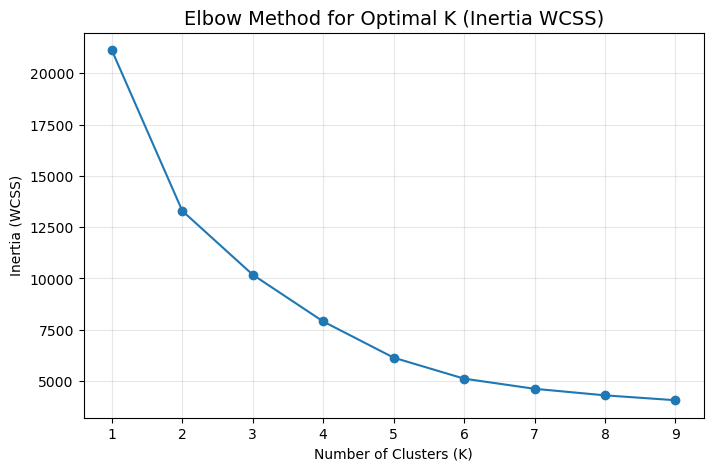

In [154]:

inertia = []

k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(tenure_std)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method for Optimal K (Inertia WCSS)", fontsize=14)
plt.grid(alpha=0.3)
plt.show()

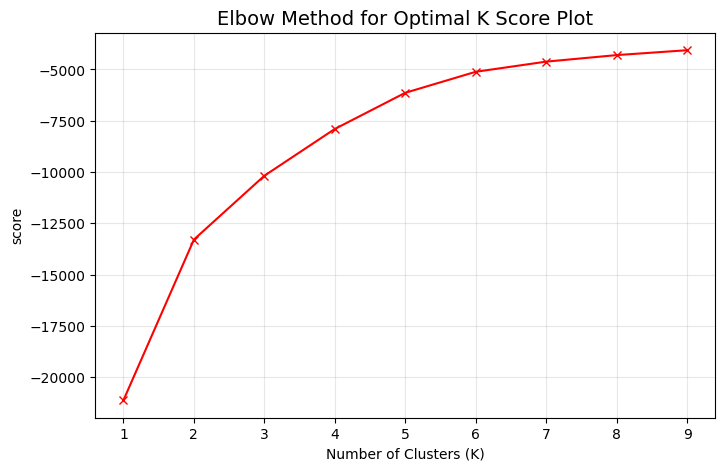

In [155]:
score1 = []

k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(tenure_std)
    score1.append(kmeans.score(tenure_std))

plt.figure(figsize=(8,5))
plt.plot(k_range, score1, marker='x',color = "red")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("score")
plt.title("Elbow Method for Optimal K Score Plot", fontsize=14)
plt.grid(alpha=0.3)
plt.show()

## The elbow method indicates an optimal cluster count of 4, as inertia decreases sharply until K=4 and then flattens, suggesting diminishing returns beyond this point.

## This allows the buisness to design cluster specific retention and pricing strategies instead of one-size to fit improve marketing efficiencies and customer life time values

# Silhouette Score

In [156]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

In [157]:
for i in range(2,7):
        kmean_seg = KMeans(n_clusters= i, random_state=42)
        labels_cluster = kmean_seg.fit_predict(tenure_std)
        sill_score = silhouette_score(tenure_std,labels_cluster)
        print(f"Silhouette Score of Cluster {i}", sill_score)

Silhouette Score of Cluster 2 0.33918504412295236
Silhouette Score of Cluster 3 0.3186947554591276
Silhouette Score of Cluster 4 0.32939662485802296
Silhouette Score of Cluster 5 0.3561779800982262
Silhouette Score of Cluster 6 0.35353375499074435


## Silhouette Score of Cluster 5 0.3561779800982262 and Silhouette Score of Cluster 6 0.35353375499074435 have a better score 
## Elbow suggested cluster 4 
## For simpler segmentation Easier buisness explanation and Clear cluster Interpretation

In [158]:
kmean_seg_sep = KMeans(n_clusters= 4, random_state=42)
labels_cluster_sep = kmean_seg_sep.fit_predict(tenure_std)

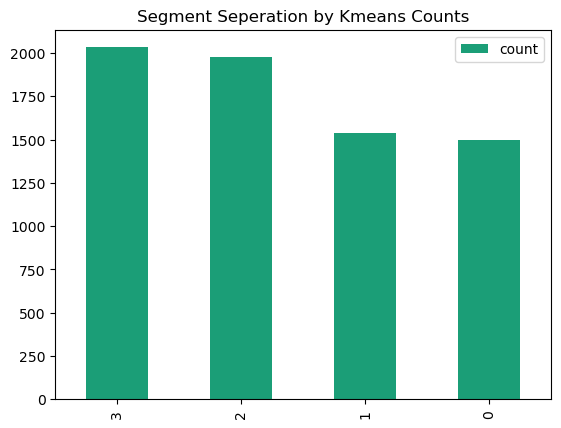

In [159]:
plt.title("Segment Seperation by Kmeans Counts")
pd.Series(labels_cluster_sep).value_counts().plot(kind = "bar",cmap="Dark2")
plt.legend()

In [160]:
grp_kmean = ibdata[["Total Revenue","Tenure in Months","Monthly Charge","Churn Binary"]]

In [161]:
grp_kmean["Churn Binary"].value_counts()

Churn Binary
0    5174
1    1869
Name: count, dtype: int64

In [162]:
grp_kmean_filt = grp_kmean

In [163]:
grp_kmean_filt["Cluster"] = labels_cluster_sep

C:\Users\AKILAN M\AppData\Local\Temp\ipykernel_17604\3514796167.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grp_kmean_filt["Cluster"] = labels_cluster_sep


In [164]:
grp_kmean_filt.groupby("Cluster")[["Total Revenue","Tenure in Months","Monthly Charge","Churn Binary"]].mean()

,Total Revenue,Tenure in Months,Monthly Charge,Churn Binary
Cluster,,,,
0,1669.483271,35.165217,25.677692,0.094314
1,1397.964828,13.260559,75.994997,0.485380
2,6899.185690,60.473445,89.716768,0.137076
3,1517.763888,17.501969,60.729380,0.349409


## Cluster 2 Premium Loyal Customers
## Higher Revenue (6899) Longest tenure (60 months) High monthly charge (89) Low churn (13%)
## Long Term High Paying and Stable customers
## Buisness Action: Protect aggresively VIP program Priority support
## Cluster 0 Budget Stable Customers
## Medium revenue 35 month tenure, very low monthly charge(25) Very low churn (9%)
## Cheap plan users Long-term Very loyal
## Low-cost digital servicing Cross-sell mid-tier plans Do not overspend retention
## Cluster 1  High Risk Early Premium
## Short tenure (13 months) High monthly charge (76) Very high churn 48.5%
## This is dangerous Almost half churn. Customers join premium Leave early Maybe pricing shock Poor onboarding
## Immediate retention focus Improve onboarding Early engagement campaigns Contract incentives This cluster has highest retention ROI.
## Cluster 3  Mid-Tier Unstable
## 17 months tenure Medium monthly (60) High churn 35%
## Not cheap Not premium Moderate value Still unstable 
## Moderate retention campaigns Targeted offers


In [165]:
cus_segment = ibdata.copy()

In [166]:
cus_segment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 59 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   Customer ID                        7043 non-null   object  
 1   Gender                             7043 non-null   object  
 2   Age                                7043 non-null   int64   
 3   Under 30                           7043 non-null   object  
 4   Senior Citizen                     7043 non-null   object  
 5   Married                            7043 non-null   object  
 6   Dependents                         7043 non-null   object  
 7   Number of Dependents               7043 non-null   int64   
 8   Country                            7043 non-null   object  
 9   State                              7043 non-null   object  
 10  City                               7043 non-null   object  
 11  Zip Code                           7043 non

In [167]:
cus_segment["Churn Binary"].value_counts()

Churn Binary
0    5174
1    1869
Name: count, dtype: int64

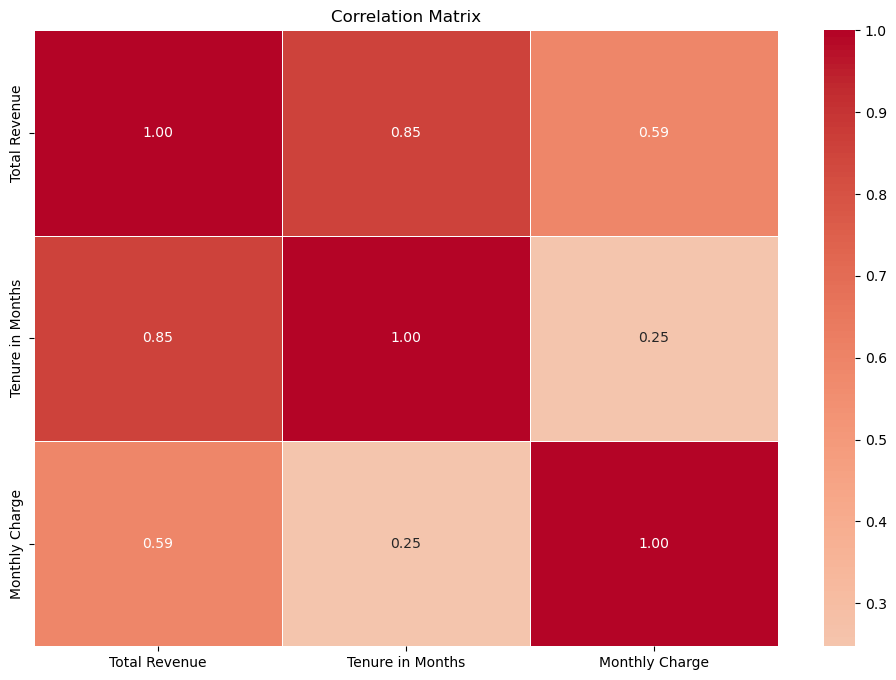

In [168]:
plt.figure(figsize=(12,8))
sb.heatmap(correv,
           annot=True,
           fmt=".2f",
           cmap="coolwarm",
           center=0,
           linewidths=0.5)

plt.title("Correlation Matrix")
plt.show()


## Churn Score is usually generated using churn behavior. It leaks target information.
## CLTV Customer Lifetime Value depends on churn
## Total Revenue ≈ Monthly Charge × Tenure So it indirectly contains: How long the customer stayed How much they already paid
## But churn risk is strongly related to tenure 
## if you already have: Tenure and Monthly Charge Then Total Revenue becomes redundant.

In [169]:
## Excluding non-informative and data leakage features prior to model development

drop_cols = ["Customer ID",
             "Country",
             "State",
             "City",
             "Zip Code",
             "Latitude",
             "Longitude",
             "Customer Status",
             "Churn Score",
             "Churn Category",
             "Churn Reason",
             "CLTV",
             "Total Revenue",
             "Total Charges",
             "Total Refunds",
             "Total Extra Data Charges",
             "Total Long Distance Charges",
             "tenure_cut",
             "Revenue Bucket",
             "Age Group",
             "Under 30",
             "Senior Citizen",
             "Dependents",
             "cluster"]

ib_model = ibdata.drop(columns=drop_cols)

In [170]:
ib_model.head()

,Gender,Age,Married,Number of Dependents,Population,Quarter,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Satisfaction Score,Churn Label,Churn Binary,GB_Group,AddOn_Count,City_Grouped,Streaming_Count
0,Male,78,No,0,68701,Q3,No,0,1,NaN,No,0.00,0,Yes,DSL,8,No,No,Yes,No,No,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,39.65,3,Yes,1,Medium,1,Los Angeles,1
1,Female,74,Yes,1,55668,Q3,Yes,1,8,Offer E,Yes,48.85,1,Yes,Fiber Optic,17,No,Yes,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,80.65,3,Yes,1,Medium,1,Los Angeles,0
2,Male,71,No,3,47534,Q3,No,0,18,Offer D,Yes,11.33,1,Yes,Fiber Optic,52,No,No,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,2,Yes,1,Very High,0,Los Angeles,3
3,Female,78,Yes,1,27778,Q3,Yes,1,25,Offer C,Yes,19.76,0,Yes,Fiber Optic,12,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2,Yes,1,Medium,2,Other,2
4,Female,80,Yes,1,26265,Q3,Yes,1,37,Offer C,Yes,6.33,1,Yes,Fiber Optic,14,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,2,Yes,1,Medium,0,Whittier,0


In [171]:
num_cols_dr = ib_model.select_dtypes(include=['number']).columns.tolist()
cat_cols_dr = ib_model.select_dtypes(include=['object']).columns.tolist()

In [172]:
print(*ib_model.columns, sep="\n")

Gender
Age
Married
Number of Dependents
Population
Quarter
Referred a Friend
Number of Referrals
Tenure in Months
Offer
Phone Service
Avg Monthly Long Distance Charges
Multiple Lines
Internet Service
Internet Type
Avg Monthly GB Download
Online Security
Online Backup
Device Protection Plan
Premium Tech Support
Streaming TV
Streaming Movies
Streaming Music
Unlimited Data
Contract
Paperless Billing
Payment Method
Monthly Charge
Satisfaction Score
Churn Label
Churn Binary
GB_Group
AddOn_Count
City_Grouped
Streaming_Count


In [173]:
## Number int columns after drop

num_cols_dr

['Age',
 'Number of Dependents',
 'Population',
 'Number of Referrals',
 'Tenure in Months',
 'Avg Monthly Long Distance Charges',
 'Multiple Lines',
 'Avg Monthly GB Download',
 'Monthly Charge',
 'Satisfaction Score',
 'Churn Binary',
 'AddOn_Count',
 'Streaming_Count']

## Customer Risk Segmentation using the Selected LightGBM Model
## Customers are segmented into four risk categories based on predicted churn probability:

## - Low Risk
## - Medium Risk
## - High Risk
## - Very High Risk

In [369]:
y_test.mean()

np.float64(0.2654364797728886)

## The most predicts in the Data is towards 26 hence biased towards non churn

(array([865.,  48.,  30.,  20.,  16.,  11.,   8.,  13.,  13.,   6.,   3.,
          7.,   5.,   8.,   8.,  14.,  13.,  12.,  12., 297.]),
 array([1.04046678e-04, 5.00898183e-02, 1.00075590e-01, 1.50061362e-01,
        2.00047133e-01, 2.50032905e-01, 3.00018677e-01, 3.50004448e-01,
        3.99990220e-01, 4.49975992e-01, 4.99961763e-01, 5.49947535e-01,
        5.99933306e-01, 6.49919078e-01, 6.99904850e-01, 7.49890621e-01,
        7.99876393e-01, 8.49862165e-01, 8.99847936e-01, 9.49833708e-01,
        9.99819480e-01]),
 <BarContainer object of 20 artists>)

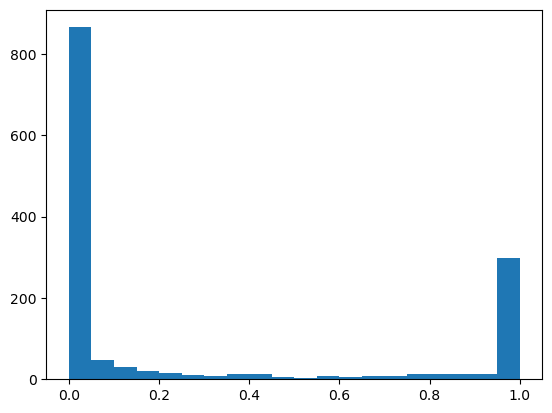

In [370]:
plt.hist(y_pred_prob_LGB[:,1], bins=20)

In [371]:
high_risk = y_pred_prob_LGB[:,1] > 0.7
y_test[high_risk].mean()

np.float64(0.952247191011236)

In [372]:
print(sum((y_pred_prob_LGB[:,1] > 0.7) & (y_test == 1)) / sum(y_test == 1))

0.9064171122994652


## At a 0.7 threshold, the model captures over 90% of actual churners, demonstrating strong sensitivity and making it highly suitable for proactive retention targeting.

In [373]:
sum(y_pred_prob_LGB[:,1] > 0.7) / len(y_test)

np.float64(0.2526614620298084)

## By targeting only 25% of customers, the company can proactively intervene on 90% of total churners.

## That is huge cost efficiency.

## Instead of sending retention offers to everyone, company can focus on a small high-risk segment

In [374]:
risk_bal = pd.DataFrame({"prob": y_pred_prob_LGB[:,1],"actual": y_test})

risk_bal["risk_group"] = pd.qcut(risk_bal["prob"], 4,labels=["Low","Medium","High","Very High"])

In [375]:
risk_bal["risk_group"].value_counts()

risk_group
Low          353
Medium       352
High         352
Very High    352
Name: count, dtype: int64

In [376]:
quad = risk_bal.groupby("risk_group")["actual"].mean()
quad

C:\Users\AKILAN M\AppData\Local\Temp\ipykernel_17604\3129534044.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quad = risk_bal.groupby("risk_group")["actual"].mean()


risk_group
Low          0.000000
Medium       0.000000
High         0.107955
Very High    0.954545
Name: actual, dtype: float64

## The Very High risk segment exhibits a 95% churn rate, indicating that the model effectively concentrates churn-prone customers into this group. 

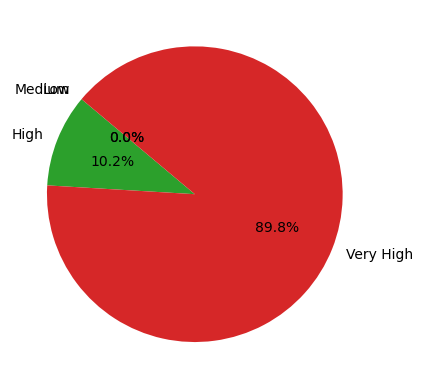

In [377]:
plt.pie(quad.values,labels=quad.index,autopct='%1.1f%%',startangle=140)

plt.show()

## Customers were segmented into four risk tiers based on predicted churn probability (quartile-based segmentation).

## The analysis revealed a strong concentration of churners in the highest risk segment:

## The Very High Risk group exhibited a 95% actual churn rate, indicating strong model enrichment.

## The High Risk group showed a moderate churn rate (11%).

## The Low and Medium Risk groups had negligible churn incidence.

## This demonstrates that the model effectively isolates customers at imminent risk of churn, enabling highly targeted retention strategies.

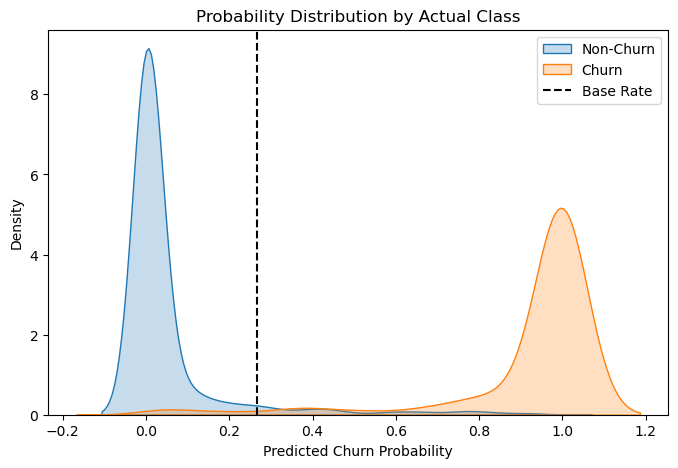

In [378]:
plt.figure(figsize=(8,5))

sb.kdeplot(risk_bal[risk_bal["actual"]==0]["prob"], label="Non-Churn", fill=True)
sb.kdeplot(risk_bal[risk_bal["actual"]==1]["prob"], label="Churn", fill=True)

plt.axvline(0.2654, color='black', linestyle='--', label="Base Rate")
plt.legend()
plt.title("Probability Distribution by Actual Class")
plt.xlabel("Predicted Churn Probability")
plt.ylabel("Density")
plt.show()

## The baseline churn rate in the dataset is 26.5%. However, the model’s top risk segment exhibits churn rates exceeding 90%, demonstrating strong uplift and targeted retention capability.

In [379]:
x_test.index[:5]
ibdata.index[:5]

RangeIndex(start=0, stop=5, step=1)

In [380]:
risk_bal = risk_bal.merge(
    ibdata[["Tenure in Months","Monthly Charge", "Total Charges","Contract"]],
    left_index=True,
    right_index=True,
    how="left")

In [381]:
x_test.index.isin(ibdata.index).all()

np.True_

In [382]:
len(ibdata)

7043

In [383]:
risk_bal.groupby("risk_group")["Tenure in Months"].mean()

C:\Users\AKILAN M\AppData\Local\Temp\ipykernel_17604\692548303.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_bal.groupby("risk_group")["Tenure in Months"].mean()


risk_group
Low          44.376771
Medium       33.877841
High         32.397727
Very High    16.920455
Name: Tenure in Months, dtype: float64

## The segmentation reveals a clear inverse relationship between tenure and churn risk. Customers in the Very High risk segment have significantly lower average tenure 17 months, indicating early lifecycle vulnerability. In contrast, Low-risk customers exhibit long-term engagement 45 months, suggesting strong retention stability.

In [384]:
risk_bal["tenure_bucket"] = pd.cut(
    risk_bal["Tenure in Months"],
    bins=[0,12,24,36,48,60,72],
    labels=["0-1yr","1-2yr","2-3yr","3-4yr","4-5yr","5-6yr"])

In [385]:
risk_bal.groupby("tenure_bucket")["actual"].mean()

C:\Users\AKILAN M\AppData\Local\Temp\ipykernel_17604\90033611.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_bal.groupby("tenure_bucket")["actual"].mean()


tenure_bucket
0-1yr    0.473923
1-2yr    0.271795
2-3yr    0.239130
3-4yr    0.163636
4-5yr    0.112500
5-6yr    0.087121
Name: actual, dtype: float64

In [386]:
risk_bal.groupby("tenure_bucket")["risk_group"].value_counts(normalize=True)

C:\Users\AKILAN M\AppData\Local\Temp\ipykernel_17604\942792187.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_bal.groupby("tenure_bucket")["risk_group"].value_counts(normalize=True)


tenure_bucket  risk_group
0-1yr          Very High     0.464853
               Medium        0.226757
               High          0.213152
               Low           0.095238
1-2yr          High          0.266667
               Low           0.261538
               Very High     0.251282
               Medium        0.220513
2-3yr          High          0.320652
               Medium        0.266304
               Very High     0.211957
               Low           0.201087
3-4yr          Medium        0.321212
               High          0.296970
               Low           0.248485
               Very High     0.133333
4-5yr          Low           0.400000
               High          0.262500
               Medium        0.218750
               Very High     0.118750
5-6yr          Low           0.446970
               Medium        0.272727
               High          0.212121
               Very High     0.068182
Name: proportion, dtype: float64

## 0–1 Year Customers
## Early lifecycle is highly unstable.
## Onboarding or value realization may be weak.
## This is where churn prevention should focus heavily.
## 1–3 Years Customers
## Customers are still vulnerable but not extreme as Risk become balanced
## Competitive pressure phase.
## Pricing or contract renewal phase.
## Intervention should be selective.
## 3–4 Years Customers
## Very High drops to 13%.
## Low risk increases gradually, Customers are stabilizing
## 4–6 Years Customers
## Long tenure customers are stable.
## Loyalty effect visible.
## Retention cost here should be minimal.

In [387]:
risk_bal.groupby("risk_group")["Monthly Charge"].mean()

C:\Users\AKILAN M\AppData\Local\Temp\ipykernel_17604\4017326971.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_bal.groupby("risk_group")["Monthly Charge"].mean()


risk_group
Low          55.735836
Medium       64.763494
High         60.775000
Very High    75.727983
Name: Monthly Charge, dtype: float64

## Low Risk (56)
## Lower pricing Possibly basic plan Customers comfortable with cost
## Less price sensitivity
## Medium / High (61–64)
## Mid-tier plans Moderate pricing pressure Mixed risk Competitive zone
## Very High (75.8)
## Customers paying more are more likely to leave.
## Competitor offering cheaper plans Customer not using full benefits
## Billing dissatisfaction
## Price increase after contract renewal

## The Very High risk segment is characterized by significantly higher average monthly charges 76 and shorter tenure (17 months), indicating that early-stage premium customers are highly vulnerable to churn. 
## This suggests potential pricing sensitivity or unmet value expectations.

## Very High segment contributes large revenue share comparitively 
## Urgent retention priority.

## Revenue Loss Concentration Monthly 

In [388]:
risk_bal["Monthly Charge"].max(), risk_bal["Monthly Charge"].min()

(118.65, 18.25)

In [389]:
risk_bal["revenue_risk"] = risk_bal["Monthly Charge"] * risk_bal["prob"]

In [390]:
risk_bal.groupby("risk_group")["Monthly Charge"].sum()

C:\Users\AKILAN M\AppData\Local\Temp\ipykernel_17604\2288052194.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_bal.groupby("risk_group")["Monthly Charge"].sum()


risk_group
Low          19674.75
Medium       22796.75
High         21392.80
Very High    26656.25
Name: Monthly Charge, dtype: float64

## Customer Lifetime Revenue (CLV proxy)

In [391]:
risk_bal.groupby("risk_group")["revenue_risk"].sum()

C:\Users\AKILAN M\AppData\Local\Temp\ipykernel_17604\3546538142.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_bal.groupby("risk_group")["revenue_risk"].sum()


risk_group
Low              8.183377
Medium          45.743515
High          3399.036520
Very High    25999.749544
Name: revenue_risk, dtype: float64

## Low and Medium Risk Customers have almost zero lifetime value
## High to moderate Very High to extremely high lifetime revenue
## Revenue increases massively from High to Very High.
## Very High risk customers are long-tenure / high-value customers.

## From both Revenue Loss Concentration Monthly and CLV, the Customers who stayed longer are now in very high risk 

In [392]:
risk_bal["charge_bucket"] = pd.cut(
    risk_bal["Monthly Charge"],
    bins=[0, 40, 60, 80, 120],
    labels=["Low", "Mid", "High", "Premium"])

# Feature Interaction Checks

## Tenure bucket interction with Charge buckets 

In [393]:
pd.pivot_table(risk_bal,values="actual",index="tenure_bucket",
                columns="charge_bucket")

C:\Users\AKILAN M\AppData\Local\Temp\ipykernel_17604\2967667164.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(risk_bal,values="actual",index="tenure_bucket",


charge_bucket,Low,Mid,High,Premium
tenure_bucket,,,,
0-1yr,0.221374,0.458333,0.600000,0.685393
1-2yr,0.072464,0.250000,0.325000,0.500000
2-3yr,0.040000,0.068966,0.307692,0.424242
3-4yr,0.000000,0.130435,0.133333,0.277778
4-5yr,0.000000,0.050000,0.058824,0.187500
5-6yr,0.018182,0.000000,0.035714,0.134615


## Early-stage premium customers are not perceiving enough value
## Reasons might be Overpriced onboarding Feature under-utilization
## Poor expectation setting Competitor offering cheaper entry plans
## Mid Tenure (1–3 Years) Premium (42%) and High Charge is also 30% Price sensitive present
## four plus years Loyalty effect reduces price sensitivity over time.
## Long-term customers tolerate higher pricing.

## High-price customers in their early lifecycle exhibit significantly elevated churn risk (up to 68%), whereas long-tenure premium customers remain relatively stable. This indicates that price sensitivity is strongest during early engagement stages.

In [394]:
risk_bal.groupby("risk_group")["Contract"].value_counts(normalize=True)

C:\Users\AKILAN M\AppData\Local\Temp\ipykernel_17604\2672737251.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_bal.groupby("risk_group")["Contract"].value_counts(normalize=True)


risk_group  Contract      
Low         Two Year          0.492918
            One Year          0.334278
            Month-to-Month    0.172805
Medium      Month-to-Month    0.531250
            Two Year          0.281250
            One Year          0.187500
High        Month-to-Month    0.471591
            One Year          0.292614
            Two Year          0.235795
Very High   Month-to-Month    0.906250
            One Year          0.079545
            Two Year          0.014205
Name: proportion, dtype: float64

# Low Risk Segment
## Low-risk customers are mostly on long-term contracts.
## High switching cost Contract lock-in Stable relationship Predictable revenue
# Medium Risk Segment
## Month to month dominates 
## Customers have flexibility to leave Moderate churn exposure
# Very High Churn Segment
## 90% of Very High risk customers are Month-to-Month
# Contract flexibility is the strongest churn driver.
## Month-to-Month = low switching barrier
## Two-Year = high switching barrier

In [395]:
risk_bal.head()

,prob,actual,risk_group,Tenure in Months,Monthly Charge,Total Charges,Contract,tenure_bucket,revenue_risk,charge_bucket
803,0.000508,0,Low,43,84.85,3645.60,Two Year,3-4yr,0.043129,Premium
3549,0.000335,0,Low,68,109.05,7508.55,Two Year,5-6yr,0.036549,Premium
3515,0.000867,0,Medium,59,18.40,1057.85,Two Year,4-5yr,0.015944,Low
5162,0.002842,0,Medium,29,26.10,692.55,Two Year,2-3yr,0.074184,Low
4642,0.000530,0,Low,68,85.00,5607.75,Two Year,5-6yr,0.045019,Premium


In [396]:
risk_bal["risk_group"].unique()

['Low', 'Medium', 'High', 'Very High']
Categories (4, object): ['Low' < 'Medium' < 'High' < 'Very High']

In [397]:
risk_category = {'Low':0,'Medium':1,'High':2,'Very High':3}

In [398]:
risk_bal["risk_num"] = risk_bal["risk_group"].map(risk_category)

In [399]:
plot_df = risk_bal[[
    "risk_group",
    "Tenure in Months",
    "Monthly Charge"]].copy()

plot_df.columns = ["risk_group","Tenure","MonthlyCharges"]

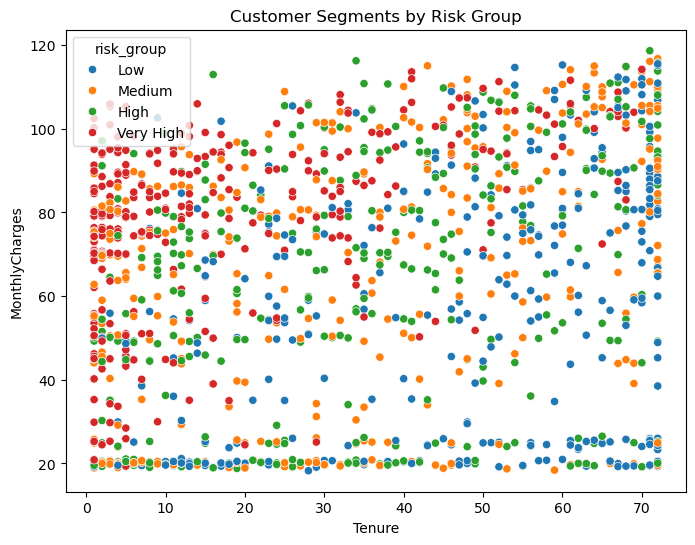

In [400]:
plt.figure(figsize=(8,6))

sb.scatterplot(
    data=plot_df,
    x="Tenure",
    y="MonthlyCharges",
    hue="risk_group"
)

plt.title("Customer Segments by Risk Group")
plt.show()

## High churn risk is concentrated at low tenure
## Customers with tenure < 10–15 months show more High / Very High risk.
## This indicates new customers are more likely to churn.

## High monthly charges increase churn risk (Red)
## Many High / Very High risk customers are in the 80–110 monthly charge range.
## Higher cost plans tend to increase churn probability.
## Possible reason:
## Customers may feel plans are expensive or not worth the value.

## High monthly charges increase churn risk (Blue) conc 
## Many High / Very High risk customers are in the 80–110 monthly charge range.
## Higher cost plans tend to increase churn probability.
## Possible reason:
## Customers may feel plans are expensive or not worth the value.

## High monthly charges increase churn risk
## Many High / Very High risk customers are in the 80–110 monthly charge range.
## Higher cost plans tend to increase churn probability.
## Possible reason: Customers may feel plans are expensive or not worth the value.

# Customer Cluster (Risk Level)

In [401]:
X = risk_bal[["Tenure in Months","Monthly Charge"]]

kmeans = KMeans(n_clusters=4, random_state=42)
risk_bal["Cluster"] = kmeans.fit_predict(X)

<Axes: xlabel='Tenure in Months', ylabel='Monthly Charge'>

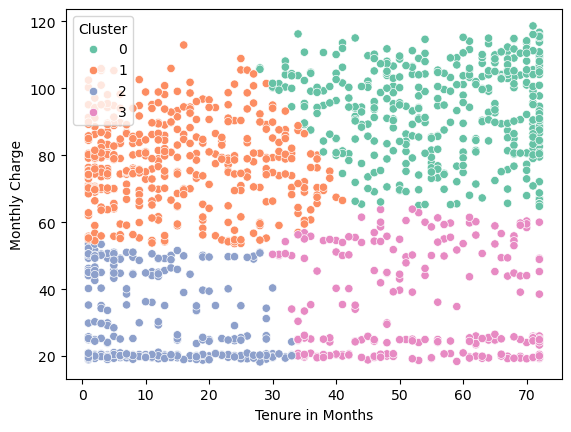

In [402]:
sb.scatterplot(
    data=risk_bal,
    x="Tenure in Months",
    y="Monthly Charge",
    hue="Cluster",
    palette="Set2")

## Cluster 0 (Green)
## High monthly charges
## Medium to high tenure High revenue customers Important to retain

## Cluster 1 (Orange)
## Medium monthly charges
## Low to medium tenure standard plan customers.

## Cluster 2 (Blue)
## Low monthly charges
## Mostly low tenure Budget customers / new users.
## Possible characteristics: Cheap plans Price sensitive

## Cluster 3 (Purple)
## Low monthly charges
## High tenure
## Long-term basic plan users.
## These customers:Stay long Generate low revenue very stable

## The EDA showed that new customers and customers with higher monthly charges tend to churn more. 
## When we analyzed the predicted churn risk groups from the model, the high-risk customers were concentrated in the same regions. 
## This indicates that the model predictions are consistent with the patterns observed during exploratory data analysis, increasing confidence in the model's reliability

# Key Insight from Customer Segmentation Analysis

## Using the selected model Light GBM, cunstomers where segmented into 
## Low Risk
## Medium Risk
## High Risk
## Very High Risk
## High-risk customers are mainly new customers with higher monthly charges, which matches patterns observed in the exploratory data analysis.

## Business Recommendation
## Telecom companies should focus retention strategies on:
## New customers (0–12 months)
## High monthly charge customers
## Possible strategies include introductory offers, loyalty rewards, and plan optimization.